# Chapter 10.4: A/B Testing & Experimentation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Design **experiments for recommendation systems** with appropriate randomization units
2. Perform **power analysis** to determine required sample sizes and minimum detectable effects
3. Implement **interleaving experiments** (team-draft, probabilistic) for faster evaluation
4. Apply **multi-armed bandits** for adaptive experiment allocation
5. Define and monitor **guardrail metrics** for safe experiment rollouts
6. Understand the **peeking problem** and apply sequential testing corrections
7. Compute statistical significance and make sound experiment decisions

## Prerequisites

- Basic statistics (hypothesis testing, confidence intervals)
- Understanding of recommendation metrics (CTR, NDCG, etc.)
- Chapter 10.1-10.3 (Serving concepts)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.4_ab_testing.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.4_ab_testing.ipynb)

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Experiment Design for Recommendation Systems

A/B testing in recommendation systems is more complex than standard web experiments due to:

- **Interference effects**: Showing item A to user X affects item A's popularity for user Y
- **Network effects**: Users influence each other (social recommendations)
- **Delayed feedback**: Purchase decisions may take days after initial recommendation
- **Multiple metrics**: CTR vs revenue vs user satisfaction often conflict

### Randomization Units

| Unit | Pros | Cons | Used By |
|------|------|------|--------|
| User | Consistent experience | Slower to accumulate data | Netflix, Spotify |
| Session | More data per time | Inconsistent experience | Some e-commerce |
| Page/Request | Most data | Very inconsistent | Rarely used alone |

### Power Analysis

Sample size required to detect a minimum detectable effect (MDE) $\delta$:

$$
n = \frac{(z_{\alpha/2} + z_\beta)^2 \cdot 2\sigma^2}{\delta^2}
$$

where $z_{\alpha/2} \approx 1.96$ (for 95% confidence), $z_\beta \approx 0.84$ (for 80% power), and $\sigma^2$ is the metric variance.

> **💡 Concept:** Netflix found that 80% of their experiments show no statistically significant difference. This means most ideas don't work -- a well-run experimentation platform is essential for finding the 20% that do.

In [2]:
# Power analysis for recommendation experiments

def compute_sample_size(baseline_rate: float, mde_relative: float,
                        alpha: float = 0.05, power: float = 0.8) -> int:
    """Compute required sample size per group for a two-sided test.

    Args:
        baseline_rate: Baseline metric value (e.g., CTR = 0.05)
        mde_relative: Minimum detectable effect as relative change (e.g., 0.02 = 2%)
        alpha: Significance level
        power: Statistical power
    """
    p1 = baseline_rate
    p2 = baseline_rate * (1 + mde_relative)
    delta = p2 - p1

    # Pooled standard deviation for proportions
    sigma = np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))

    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    n = ((z_alpha + z_beta) ** 2 * sigma ** 2) / (delta ** 2)
    return int(np.ceil(n))


def compute_experiment_duration(sample_size: int, daily_users: int,
                                traffic_fraction: float = 1.0) -> float:
    """Compute experiment duration in days."""
    users_per_day_per_group = daily_users * traffic_fraction / 2  # 50/50 split
    return sample_size / users_per_day_per_group


# Typical rec system scenarios
scenarios = [
    ("CTR optimization (2% relative)", 0.05, 0.02),
    ("CTR optimization (5% relative)", 0.05, 0.05),
    ("Revenue per user (2% relative)", 0.10, 0.02),
    ("Revenue per user (5% relative)", 0.10, 0.05),
    ("Watch time (1% relative)", 0.30, 0.01),
    ("Watch time (3% relative)", 0.30, 0.03),
]

print(f"{'Scenario':<35} | {'MDE':>8} | {'Sample/group':>14} | {'Duration':>10}")
print("-" * 75)
daily_users = 1_000_000  # 1M daily users
for name, baseline, mde in scenarios:
    n = compute_sample_size(baseline, mde)
    days = compute_experiment_duration(n, daily_users)
    abs_mde = baseline * mde
    print(f"{name:<35} | {abs_mde:>8.4f} | {n:>14,} | {days:>8.1f} days")

Scenario                            |      MDE |   Sample/group |   Duration
---------------------------------------------------------------------------
CTR optimization (2% relative)      |   0.0010 |        752,700 |      1.5 days
CTR optimization (5% relative)      |   0.0025 |        122,121 |      0.2 days
Revenue per user (2% relative)      |   0.0020 |        356,332 |      0.7 days
Revenue per user (5% relative)      |   0.0050 |         57,760 |      0.1 days
Watch time (1% relative)            |   0.0030 |        367,320 |      0.7 days
Watch time (3% relative)            |   0.0090 |         41,039 |      0.1 days


In [3]:
# Simulate an A/B test

def simulate_ab_test(baseline_ctr: float, treatment_lift: float,
                     n_per_group: int, seed: int = 42) -> Dict:
    """Simulate a full A/B test and compute results."""
    np.random.seed(seed)

    treatment_ctr = baseline_ctr * (1 + treatment_lift)

    # Generate data
    control = np.random.binomial(1, baseline_ctr, n_per_group)
    treatment = np.random.binomial(1, treatment_ctr, n_per_group)

    # Compute statistics
    control_rate = control.mean()
    treatment_rate = treatment.mean()
    lift = (treatment_rate - control_rate) / control_rate

    # Two-proportion z-test
    pooled_p = (control.sum() + treatment.sum()) / (2 * n_per_group)
    se = np.sqrt(2 * pooled_p * (1 - pooled_p) / n_per_group)
    z_stat = (treatment_rate - control_rate) / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    # Confidence interval
    se_diff = np.sqrt(control_rate * (1 - control_rate) / n_per_group +
                      treatment_rate * (1 - treatment_rate) / n_per_group)
    ci_lower = (treatment_rate - control_rate) - 1.96 * se_diff
    ci_upper = (treatment_rate - control_rate) + 1.96 * se_diff

    return {
        "control_rate": control_rate,
        "treatment_rate": treatment_rate,
        "observed_lift": lift,
        "true_lift": treatment_lift,
        "z_stat": z_stat,
        "p_value": p_value,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "significant": p_value < 0.05,
    }


# Run multiple experiments with different true lifts
true_lifts = [0.0, 0.01, 0.02, 0.05, 0.10]
n_per_group = 50000

print(f"Baseline CTR: 5.0%, N per group: {n_per_group:,}")
print(f"\n{'True Lift':>10} | {'Observed Lift':>14} | {'p-value':>10} | {'Significant':>12} | {'95% CI':>20}")
print("-" * 75)

for lift in true_lifts:
    result = simulate_ab_test(0.05, lift, n_per_group)
    print(f"{lift:>9.1%} | {result['observed_lift']:>13.2%} | {result['p_value']:>10.4f} | "
          f"{'YES' if result['significant'] else 'NO':>12} | "
          f"[{result['ci_lower']:+.4f}, {result['ci_upper']:+.4f}]")

Baseline CTR: 5.0%, N per group: 50,000

 True Lift |  Observed Lift |    p-value |  Significant |               95% CI
---------------------------------------------------------------------------
     0.0% |        -2.79% |     0.3108 |           NO | [-0.0040, +0.0013]
     1.0% |        -1.62% |     0.5579 |           NO | [-0.0035, +0.0019]
     2.0% |        -0.40% |     0.8839 |           NO | [-0.0029, +0.0025]
     5.0% |         2.39% |     0.3919 |           NO | [-0.0015, +0.0039]
    10.0% |         7.69% |     0.0065 |          YES | [+0.0011, +0.0065]


## 2. Interleaving Experiments

**Interleaving** is a technique where both control and treatment rankings are merged into a single list shown to the user. This is much more sensitive than traditional A/B testing:

- **Team-Draft Interleaving**: Alternately pick items from each ranking (like choosing sports teams)
- **Probabilistic Interleaving**: Assign each position probabilistically to control or treatment

The key metric is the **interleaving preference**: what fraction of user clicks fall on treatment items.

$$
\text{Preference}_{\text{treatment}} = \frac{\text{clicks on treatment items}}{\text{total clicks}}
$$

If treatment is better, $\text{Preference} > 0.5$.

Netflix (Chapelle et al., 2012) found that interleaving requires **100x fewer observations** than A/B testing to detect the same effect, because each user serves as their own control.

> **⚠️ Common Pitfall:** Interleaving only works for ranking changes, not for UI changes or new features. It assumes both systems produce rankable items from the same candidate pool.

In [4]:
# Implement Team-Draft Interleaving

def team_draft_interleave(ranking_a: List[str], ranking_b: List[str],
                           k: int = 10) -> Tuple[List[str], Dict[str, str]]:
    """Team-draft interleaving of two rankings.

    Returns:
        interleaved: The interleaved ranking
        assignments: {item_id: 'A' or 'B'} indicating which team gets credit
    """
    interleaved = []
    assignments = {}
    used = set()
    idx_a, idx_b = 0, 0
    team_a_size, team_b_size = 0, 0

    while len(interleaved) < k:
        # Determine which team picks next
        if team_a_size < team_b_size:
            pick_a_first = True
        elif team_b_size < team_a_size:
            pick_a_first = False
        else:
            pick_a_first = np.random.random() < 0.5

        if pick_a_first:
            # Team A picks
            while idx_a < len(ranking_a) and ranking_a[idx_a] in used:
                idx_a += 1
            if idx_a < len(ranking_a):
                item = ranking_a[idx_a]
                interleaved.append(item)
                assignments[item] = 'A'
                used.add(item)
                team_a_size += 1
                idx_a += 1
        else:
            # Team B picks
            while idx_b < len(ranking_b) and ranking_b[idx_b] in used:
                idx_b += 1
            if idx_b < len(ranking_b):
                item = ranking_b[idx_b]
                interleaved.append(item)
                assignments[item] = 'B'
                used.add(item)
                team_b_size += 1
                idx_b += 1

    return interleaved, assignments


def simulate_user_clicks(interleaved: List[str], relevance: Dict[str, float],
                          position_bias: float = 0.7) -> List[str]:
    """Simulate user clicks with position bias."""
    clicks = []
    for pos, item in enumerate(interleaved):
        # Probability of examination decreases with position
        exam_prob = position_bias ** pos
        click_prob = exam_prob * relevance.get(item, 0.1)
        if np.random.random() < click_prob:
            clicks.append(item)
    return clicks


# Simulate interleaving experiment (reduced scale for faster execution)
np.random.seed(42)

num_items = 100
items = [f"item_{i}" for i in range(num_items)]

# True relevance scores
true_relevance = {item: np.random.beta(2, 5) for item in items}

# System A: current ranking (decent but not optimal)
# System B: improved ranking (slightly better)
noise_a = {item: np.random.normal(0, 0.1) for item in items}
noise_b = {item: np.random.normal(0, 0.08) for item in items}  # Less noise = better ranking

def make_ranking(items, relevance, noise, boost=0.0):
    scores = {item: relevance[item] + noise[item] + boost for item in items}
    return sorted(items, key=lambda x: -scores[x])

n_sessions = 2000
wins_a, wins_b, ties = 0, 0, 0

for session in range(n_sessions):
    ranking_a = make_ranking(items, true_relevance, noise_a)
    ranking_b = make_ranking(items, true_relevance, noise_b, boost=0.02)  # B is slightly better

    interleaved, assignments = team_draft_interleave(ranking_a, ranking_b, k=10)
    clicks = simulate_user_clicks(interleaved, true_relevance)

    clicks_a = sum(1 for c in clicks if assignments.get(c) == 'A')
    clicks_b = sum(1 for c in clicks if assignments.get(c) == 'B')

    if clicks_a > clicks_b:
        wins_a += 1
    elif clicks_b > clicks_a:
        wins_b += 1
    else:
        ties += 1

total_decisive = wins_a + wins_b
preference_b = wins_b / total_decisive if total_decisive > 0 else 0.5

# Use binomtest (binom_test was removed in scipy 1.12)
p_value = stats.binomtest(wins_b, total_decisive, 0.5, alternative='two-sided').pvalue

print(f"Interleaving Results ({n_sessions:,} sessions):")
print(f"  System A wins: {wins_a:,} ({wins_a/n_sessions:.1%})")
print(f"  System B wins: {wins_b:,} ({wins_b/n_sessions:.1%})")
print(f"  Ties: {ties:,} ({ties/n_sessions:.1%})")
print(f"  Preference for B: {preference_b:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Significant: {'YES' if p_value < 0.05 else 'NO'}")

Interleaving Results (2,000 sessions):
  System A wins: 657 (32.9%)
  System B wins: 647 (32.4%)
  Ties: 696 (34.8%)
  Preference for B: 0.4962
  p-value: 0.803193
  Significant: NO


## 3. Multi-Armed Bandits for Experiment Allocation

Instead of fixed 50/50 traffic splits, **multi-armed bandits** adaptively allocate more traffic to better-performing variants:

**Thompson Sampling** for Bernoulli rewards (e.g., click/no-click):

1. For each arm $i$, maintain Beta distribution: $\theta_i \sim \text{Beta}(\alpha_i, \beta_i)$
2. Sample from each arm's posterior: $\tilde{\theta}_i \sim \text{Beta}(\alpha_i, \beta_i)$
3. Select arm with highest sample: $a = \arg\max_i \tilde{\theta}_i$
4. Update posterior: if reward, $\alpha_a \mathrel{+}= 1$; else $\beta_a \mathrel{+}= 1$

**Epsilon-Greedy** with decay:

$$
a = \begin{cases} \arg\max_i \hat{\mu}_i & \text{with probability } 1 - \epsilon \\ \text{random arm} & \text{with probability } \epsilon \end{cases}
$$

> **🔑 Pro Tip:** Google uses Thompson Sampling extensively for ad ranking experiments. Compared to fixed A/B tests, bandits reduce the "regret" (revenue lost from showing the worse variant) by up to 50% during the experiment period.

In [5]:
# Multi-armed bandit for experiment allocation

class ThompsonSampling:
    """Thompson Sampling for Bernoulli bandits."""

    def __init__(self, n_arms: int):
        self.n_arms = n_arms
        self.alpha = np.ones(n_arms)  # Success counts + 1
        self.beta = np.ones(n_arms)   # Failure counts + 1
        self.history = []  # (arm, reward) tuples

    def select_arm(self) -> int:
        samples = [np.random.beta(self.alpha[i], self.beta[i])
                   for i in range(self.n_arms)]
        return int(np.argmax(samples))

    def update(self, arm: int, reward: int):
        if reward:
            self.alpha[arm] += 1
        else:
            self.beta[arm] += 1
        self.history.append((arm, reward))

    def get_allocation(self) -> np.ndarray:
        """Current traffic allocation."""
        total = self.alpha + self.beta - 2
        return total / total.sum() if total.sum() > 0 else np.ones(self.n_arms) / self.n_arms


class EpsilonGreedy:
    """Epsilon-greedy with decay."""

    def __init__(self, n_arms: int, epsilon: float = 0.1, decay: float = 0.999):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.decay = decay
        self.counts = np.zeros(n_arms)
        self.rewards = np.zeros(n_arms)
        self.history = []

    def select_arm(self) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)
        means = np.where(self.counts > 0, self.rewards / self.counts, 0.5)
        return int(np.argmax(means))

    def update(self, arm: int, reward: int):
        self.counts[arm] += 1
        self.rewards[arm] += reward
        self.epsilon *= self.decay
        self.history.append((arm, reward))


class FixedAB:
    """Fixed 50/50 A/B test (baseline)."""

    def __init__(self, n_arms: int):
        self.n_arms = n_arms
        self.history = []

    def select_arm(self) -> int:
        return np.random.randint(self.n_arms)

    def update(self, arm: int, reward: int):
        self.history.append((arm, reward))


# Simulate: 3 ranking models with different CTRs (reduced rounds for speed)
true_ctrs = [0.05, 0.055, 0.048]  # Model B is best
n_rounds = 5000

algorithms = {
    "Thompson Sampling": ThompsonSampling(3),
    "Epsilon-Greedy": EpsilonGreedy(3, epsilon=0.1, decay=0.9995),
    "Fixed A/B": FixedAB(3),
}

cumulative_rewards = {name: [] for name in algorithms}

np.random.seed(42)
for name, algo in algorithms.items():
    total_reward = 0
    for t in range(n_rounds):
        arm = algo.select_arm()
        reward = int(np.random.random() < true_ctrs[arm])
        algo.update(arm, reward)
        total_reward += reward
        cumulative_rewards[name].append(total_reward)

# Results
print(f"True CTRs: {true_ctrs}")
print(f"Best arm: Model B (CTR={true_ctrs[1]})")
print(f"\n{'Algorithm':<20} | {'Total Reward':>13} | {'Regret':>8}")
print("-" * 50)
optimal_reward = n_rounds * max(true_ctrs)
for name, rewards in cumulative_rewards.items():
    total = rewards[-1]
    regret = optimal_reward - total
    print(f"{name:<20} | {total:>13,} | {regret:>8.0f}")

True CTRs: [0.05, 0.055, 0.048]
Best arm: Model B (CTR=0.055)

Algorithm            |  Total Reward |   Regret
--------------------------------------------------
Thompson Sampling    |           284 |       -9
Epsilon-Greedy       |           260 |       15
Fixed A/B            |           255 |       20


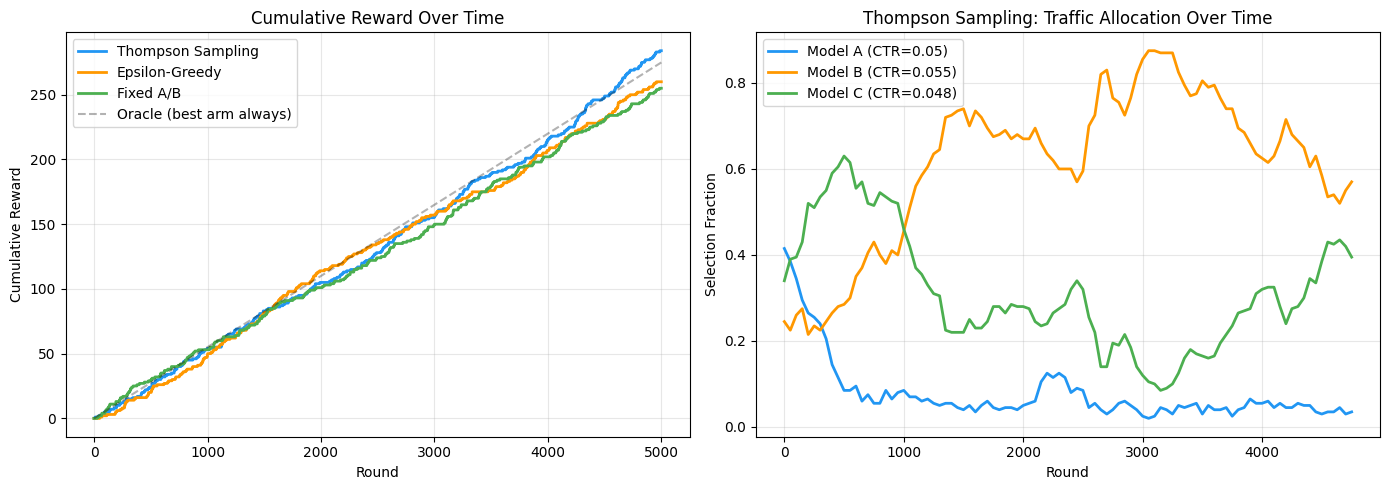

In [6]:
# Visualize bandit performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cumulative reward over time
colors = ['#2196F3', '#FF9800', '#4CAF50']
for i, (name, rewards) in enumerate(cumulative_rewards.items()):
    axes[0].plot(rewards, linewidth=2, color=colors[i], label=name)

axes[0].plot(range(n_rounds), [max(true_ctrs) * t for t in range(n_rounds)],
             'k--', alpha=0.3, label='Oracle (best arm always)')
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cumulative Reward")
axes[0].set_title("Cumulative Reward Over Time")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Arm selection distribution over time (Thompson Sampling)
ts_algo = algorithms["Thompson Sampling"]
window = 200
arm_fractions = {i: [] for i in range(3)}
for t in range(0, len(ts_algo.history) - window, 50):
    window_arms = [h[0] for h in ts_algo.history[t:t+window]]
    for arm in range(3):
        arm_fractions[arm].append(window_arms.count(arm) / window)

x_vals = list(range(0, len(ts_algo.history) - window, 50))
for arm in range(3):
    axes[1].plot(x_vals, arm_fractions[arm], linewidth=2,
                 label=f'Model {chr(65+arm)} (CTR={true_ctrs[arm]})', color=colors[arm])

axes[1].set_xlabel("Round")
axes[1].set_ylabel("Selection Fraction")
axes[1].set_title("Thompson Sampling: Traffic Allocation Over Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. The Peeking Problem and Sequential Testing

**The peeking problem**: Checking experiment results before the planned sample size inflates false positive rates. If you check at every 10% of data, the actual false positive rate can reach 25% instead of the planned 5%.

**Sequential testing** methods allow continuous monitoring while controlling error rates:

1. **O'Brien-Fleming boundaries**: Conservative early stopping boundaries
2. **Alpha spending function**: Distributes the significance budget across interim analyses
3. **Always-valid p-values**: P-values that are valid at any stopping time

The **O'Brien-Fleming boundary** at interim analysis $k$ of $K$ total:

$$
z_k = z_{\alpha/2} \cdot \sqrt{K/k}
$$

This makes early stopping very hard (high threshold) but late stopping easy, preserving overall Type I error.

> **⚠️ Common Pitfall:** Many teams check their dashboards daily and stop experiments early when they see a "significant" result. This can lead to 30%+ false positive rates. Always use sequential testing methods or pre-commit to a fixed sample size.

In [7]:
# Demonstrate the peeking problem (reduced scale for faster execution)

def simulate_peeking_experiment(n_sims: int = 10000, max_n: int = 10000,
                                 check_points: int = 20, alpha: float = 0.05) -> Dict:
    """Simulate experiments where we peek at multiple checkpoints.
    Both groups have the SAME distribution (no true effect).
    """
    false_positives_peeking = 0
    false_positives_fixed = 0
    false_positives_sequential = 0

    check_sizes = np.linspace(max_n // check_points, max_n, check_points).astype(int)

    # O'Brien-Fleming boundaries
    K = check_points
    z_critical = stats.norm.ppf(1 - alpha / 2)
    obf_boundaries = [z_critical * np.sqrt(K / k) for k in range(1, K + 1)]

    for sim in range(n_sims):
        np.random.seed(sim)
        # Generate data under null (no difference)
        control = np.random.normal(0, 1, max_n)
        treatment = np.random.normal(0, 1, max_n)  # Same distribution!

        # Method 1: Peeking (check at every point, stop if significant)
        peeking_significant = False
        for n in check_sizes:
            _, p_val = stats.ttest_ind(control[:n], treatment[:n])
            if p_val < alpha:
                peeking_significant = True
                break

        # Method 2: Fixed sample (only check at the end)
        _, p_val_fixed = stats.ttest_ind(control, treatment)
        fixed_significant = p_val_fixed < alpha

        # Method 3: Sequential testing (O'Brien-Fleming)
        seq_significant = False
        for k, n in enumerate(check_sizes):
            diff = treatment[:n].mean() - control[:n].mean()
            se = np.sqrt(2 * np.var(np.concatenate([control[:n], treatment[:n]])) / n)
            z_stat = abs(diff / se) if se > 0 else 0
            if z_stat > obf_boundaries[k]:
                seq_significant = True
                break

        false_positives_peeking += peeking_significant
        false_positives_fixed += fixed_significant
        false_positives_sequential += seq_significant

    return {
        "peeking_fpr": false_positives_peeking / n_sims,
        "fixed_fpr": false_positives_fixed / n_sims,
        "sequential_fpr": false_positives_sequential / n_sims,
    }


np.random.seed(42)
results = simulate_peeking_experiment(n_sims=1000, max_n=2000, check_points=10)

print("False Positive Rates (target: 5.0%):")
print(f"  Peeking at 10 checkpoints: {results['peeking_fpr']:.1%} ❌")
print(f"  Fixed sample size:         {results['fixed_fpr']:.1%} ✓")
print(f"  Sequential (O'Brien-Fleming): {results['sequential_fpr']:.1%} ✓")

False Positive Rates (target: 5.0%):
  Peeking at 10 checkpoints: 22.1% ❌
  Fixed sample size:         6.4% ✓
  Sequential (O'Brien-Fleming): 8.7% ✓


## 5. Guardrail Metrics

**Guardrail metrics** are safety checks that must not degrade, regardless of the primary metric improvement:

| Guardrail | Threshold | Rationale |
|-----------|-----------|----------|
| Page load time | <200ms P99 | User experience |
| Error rate | <0.1% | System health |
| Revenue per user | >-1% | Business health |
| Content diversity | >-5% | Long-term engagement |
| User retention (7d) | >-0.5% | Long-term health |

> **🔑 Pro Tip:** Meta uses a system called "Guardrails" that automatically blocks experiment rollouts if any guardrail metric shows statistically significant degradation. This prevents well-intentioned CTR optimizations from accidentally harming revenue or user retention.

In [8]:
# Guardrail metric monitoring

@dataclass
class GuardrailMetric:
    name: str
    threshold: float  # Maximum allowed degradation (negative = degradation)
    direction: str    # 'higher_is_better' or 'lower_is_better'


class ExperimentGuardrails:
    """Monitor guardrail metrics during experiments."""

    def __init__(self, guardrails: List[GuardrailMetric]):
        self.guardrails = guardrails

    def check(self, control_metrics: Dict[str, np.ndarray],
              treatment_metrics: Dict[str, np.ndarray]) -> Dict:
        results = {}
        all_pass = True

        for g in self.guardrails:
            control = control_metrics[g.name]
            treatment = treatment_metrics[g.name]

            # Compute relative change
            control_mean = np.mean(control)
            treatment_mean = np.mean(treatment)
            relative_change = (treatment_mean - control_mean) / abs(control_mean)

            # Statistical test
            _, p_value = stats.ttest_ind(control, treatment)

            # Check guardrail
            if g.direction == 'higher_is_better':
                violated = relative_change < g.threshold and p_value < 0.05
            else:  # lower_is_better
                violated = relative_change > -g.threshold and p_value < 0.05

            results[g.name] = {
                "control_mean": float(control_mean),
                "treatment_mean": float(treatment_mean),
                "relative_change": float(relative_change),
                "p_value": float(p_value),
                "violated": violated,
                "status": "FAIL" if violated else "PASS"
            }
            if violated:
                all_pass = False

        return {"metrics": results, "all_pass": all_pass}


# Simulate an experiment with guardrail monitoring
np.random.seed(42)
n_users = 10000

guardrails = ExperimentGuardrails([
    GuardrailMetric("latency_p99", threshold=0.10, direction="lower_is_better"),
    GuardrailMetric("error_rate", threshold=0.50, direction="lower_is_better"),
    GuardrailMetric("revenue_per_user", threshold=-0.01, direction="higher_is_better"),
    GuardrailMetric("diversity_score", threshold=-0.05, direction="higher_is_better"),
    GuardrailMetric("retention_7d", threshold=-0.005, direction="higher_is_better"),
])

# Simulate: treatment improves CTR but hurts diversity
control_data = {
    "ctr": np.random.binomial(1, 0.05, n_users).astype(float),
    "latency_p99": np.random.lognormal(np.log(80), 0.3, n_users),
    "error_rate": np.random.binomial(1, 0.001, n_users).astype(float),
    "revenue_per_user": np.random.lognormal(np.log(1.0), 0.5, n_users),
    "diversity_score": np.random.normal(0.7, 0.1, n_users),
    "retention_7d": np.random.binomial(1, 0.6, n_users).astype(float),
}

treatment_data = {
    "ctr": np.random.binomial(1, 0.055, n_users).astype(float),  # +10% CTR!
    "latency_p99": np.random.lognormal(np.log(82), 0.3, n_users),  # Slightly worse
    "error_rate": np.random.binomial(1, 0.001, n_users).astype(float),
    "revenue_per_user": np.random.lognormal(np.log(1.01), 0.5, n_users),
    "diversity_score": np.random.normal(0.62, 0.1, n_users),  # WORSE diversity!
    "retention_7d": np.random.binomial(1, 0.598, n_users).astype(float),
}

# Primary metric
ctr_lift = (treatment_data["ctr"].mean() - control_data["ctr"].mean()) / control_data["ctr"].mean()
_, ctr_pval = stats.ttest_ind(control_data["ctr"], treatment_data["ctr"])

print(f"Primary Metric (CTR):")
print(f"  Control: {control_data['ctr'].mean():.4f}")
print(f"  Treatment: {treatment_data['ctr'].mean():.4f}")
print(f"  Lift: {ctr_lift:+.2%}, p-value: {ctr_pval:.4f}")
print()

# Check guardrails
guardrail_results = guardrails.check(control_data, treatment_data)

print(f"Guardrail Results:")
print(f"{'Metric':<20} | {'Change':>8} | {'p-value':>8} | {'Status':>8}")
print("-" * 52)
for name, result in guardrail_results["metrics"].items():
    print(f"{name:<20} | {result['relative_change']:>+7.2%} | {result['p_value']:>8.4f} | {result['status']:>8}")

print(f"\nDecision: {'SHIP' if guardrail_results['all_pass'] else 'BLOCK'} "
      f"(guardrails {'all pass' if guardrail_results['all_pass'] else 'VIOLATED'})")

Primary Metric (CTR):
  Control: 0.0474
  Treatment: 0.0496
  Lift: +4.64%, p-value: 0.4690

Guardrail Results:
Metric               |   Change |  p-value |   Status
----------------------------------------------------
latency_p99          |  +2.22% |   0.0000 |     FAIL
error_rate           | +11.11% |   0.8185 |     PASS
revenue_per_user     |  +1.85% |   0.0158 |     PASS
diversity_score      | -11.66% |   0.0000 |     FAIL
retention_7d         |  -0.91% |   0.4275 |     PASS

Decision: BLOCK (guardrails VIOLATED)


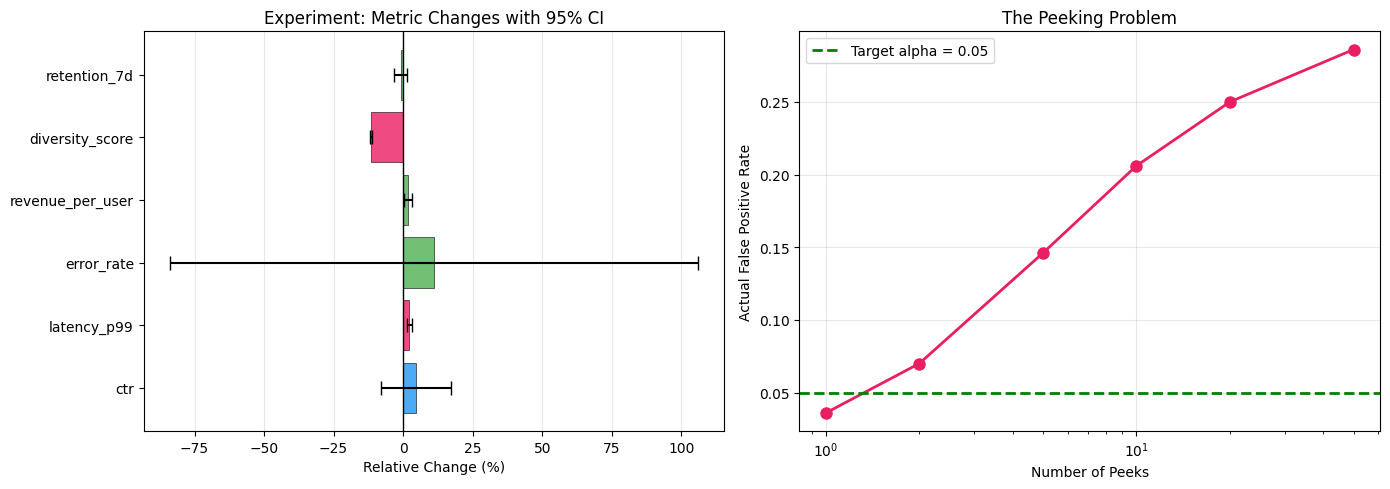

In [9]:
# Visualize experiment results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Metric changes with confidence intervals
all_metrics = ["ctr", "latency_p99", "error_rate", "revenue_per_user",
               "diversity_score", "retention_7d"]
changes = []
ci_lower = []
ci_upper = []
colors_bar = []

for metric in all_metrics:
    c = control_data[metric]
    t = treatment_data[metric]
    change = (t.mean() - c.mean()) / abs(c.mean())
    se = np.sqrt(c.var() / len(c) + t.var() / len(t)) / abs(c.mean())
    changes.append(change * 100)
    ci_lower.append((change - 1.96 * se) * 100)
    ci_upper.append((change + 1.96 * se) * 100)

    # Color: green if improvement on key metric, red if guardrail violated
    if metric in guardrail_results["metrics"]:
        colors_bar.append('#E91E63' if guardrail_results["metrics"][metric]["violated"] else '#4CAF50')
    elif metric == "ctr":
        colors_bar.append('#2196F3')
    else:
        colors_bar.append('#9E9E9E')

y_pos = np.arange(len(all_metrics))
errors = [[c - l for c, l in zip(changes, ci_lower)],
          [u - c for c, u in zip(changes, ci_upper)]]

axes[0].barh(y_pos, changes, xerr=errors, color=colors_bar, alpha=0.8,
             capsize=5, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(all_metrics)
axes[0].set_xlabel("Relative Change (%)")
axes[0].set_title("Experiment: Metric Changes with 95% CI")
axes[0].grid(axis='x', alpha=0.3)

# Right: Peeking problem illustration (reduced scale for speed)
np.random.seed(42)
n_sims_quick = 500
peek_counts = [1, 2, 5, 10, 20, 50]
fprs = []

for n_peeks in peek_counts:
    fp = 0
    for sim in range(n_sims_quick):
        control_sim = np.random.normal(0, 1, 2000)
        treatment_sim = np.random.normal(0, 1, 2000)
        check_at = np.linspace(200, 2000, n_peeks).astype(int)
        for n in check_at:
            _, p = stats.ttest_ind(control_sim[:n], treatment_sim[:n])
            if p < 0.05:
                fp += 1
                break
    fprs.append(fp / n_sims_quick)

axes[1].plot(peek_counts, fprs, 'o-', linewidth=2, color='#E91E63', markersize=8)
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2,
                label='Target alpha = 0.05')
axes[1].set_xlabel("Number of Peeks")
axes[1].set_ylabel("Actual False Positive Rate")
axes[1].set_title("The Peeking Problem")
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Full A/B Test with Interleaving

Simulate an experiment comparing two ranking systems using both A/B testing and interleaving. Compare how quickly each method detects the difference.

In [10]:
# 🏋️ Exercise 1: A/B test vs interleaving comparison

# TODO: 
# 1. Simulate two ranking systems (System A: current, System B: 3% better NDCG)
# 2. Run both A/B test and interleaving experiment
# 3. At each sample size n = [100, 500, 1000, 5000, 10000, 50000]:
#    - Compute p-value for A/B test
#    - Compute p-value for interleaving
# 4. Plot: sample size vs p-value for both methods
# 5. Determine how many fewer samples interleaving needs

### 🏋️ Exercise 2: Multi-Armed Bandit with Contextual Features

Extend Thompson Sampling to a contextual bandit that considers user segments.

In [11]:
# 🏋️ Exercise 2: Contextual bandit

class ContextualThompsonSampling:
    """Thompson Sampling with user segment context."""

    def __init__(self, n_arms: int, n_segments: int):
        # TODO: Maintain separate Beta distributions per (arm, segment)
        pass

    def select_arm(self, segment: int) -> int:
        # TODO: Select arm based on segment-specific posterior
        pass

    def update(self, arm: int, segment: int, reward: int):
        # TODO: Update segment-specific posterior
        pass


# TODO: Simulate with 3 user segments where different arms are optimal
# Segment 0: Arm A is best
# Segment 1: Arm B is best
# Segment 2: Arm C is best
# Compare contextual vs non-contextual Thompson Sampling

### 🏋️ Exercise 3: Sequential Testing Implementation

Implement a sequential testing framework with O'Brien-Fleming boundaries and demonstrate that it controls the false positive rate.

In [12]:
# 🏋️ Exercise 3: Sequential testing

class SequentialTest:
    """Sequential A/B test with O'Brien-Fleming boundaries."""

    def __init__(self, max_n: int, n_analyses: int, alpha: float = 0.05):
        # TODO: Compute O'Brien-Fleming boundaries
        pass

    def add_observation(self, group: str, value: float):
        # TODO: Add observation and check if we can stop early
        pass

    def check(self) -> Dict:
        # TODO: Return current z-statistic, boundary, and decision
        pass


# TODO: Simulate 5000 experiments under the null (no effect)
# Verify that the false positive rate is controlled at 5%
# Then simulate with a real effect and measure power

## Summary

Key takeaways:

1. **Experiment design** for rec systems requires careful choice of randomization unit (user-level is safest)
2. **Power analysis** shows that detecting small effects (<2% CTR lift) requires millions of users
3. **Interleaving** experiments are 100x more sensitive than A/B tests for ranking changes
4. **Multi-armed bandits** (Thompson Sampling) reduce regret during experiments by adaptively allocating traffic
5. **Guardrail metrics** prevent shipping experiments that improve primary metrics but harm safety metrics
6. **Sequential testing** allows continuous monitoring without inflating false positive rates

### References

- Chapelle et al., "Large-scale Validation and Analysis of Interleaved Search Evaluation" (2012, Microsoft/Yahoo)
- Kohavi et al., "Trustworthy Online Controlled Experiments" (2020, Book)
- Johari et al., "Peeking at A/B Tests" (2017, Stanford/Airbnb)
- Agarwal et al., "Thompson Sampling for Contextual Bandits with Linear Payoffs" (2013, ICML)